In [1]:
# Install if needed
# !pip install scikit-learn pandas numpy matplotlib seaborn joblib tqdm

import os
import json
import glob
import warnings
import joblib
from pathlib import Path
from datetime import datetime
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("✅ All imports successful")

✅ All imports successful


In [2]:
# ─── USER CONFIG ──────────────────────────────────────────────────────────────
MININDN_DIR = "../Logs"          # Root folder containing node subfolders
MODEL_DIR   = "../Models"           # Where to save trained model artifacts
RESULTS_DIR = "../Results"          # Where to save evaluation plots/CSVs
DATASETS_DIR = "../Datasets"          # Where to save processed datasets (optional)
# Isolation Forest hyperparameters
IF_CONTAMINATION = 0.01   # Expected fraction of anomalies (tune as needed)
IF_N_ESTIMATORS  = 200
IF_MAX_SAMPLES   = 'auto'
IF_RANDOM_STATE  = 42

# Anomaly score threshold (lower = more anomalous in sklearn; -0.1 is typical)
# We use the percentile approach for auto-thresholding after training
ANOMALY_PERCENTILE = 1 

# Feature columns produced by feature engineering
FEATURE_COLS = [
    'pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio',
    'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate',
    'out_interests_rate', 'in_data_rate', 'nack_rate'
]

# Create output directories
for d in [MODEL_DIR, RESULTS_DIR, DATASETS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"📁 Minindn root : {os.path.abspath(MININDN_DIR)}")
print(f"💾 Model output : {os.path.abspath(MODEL_DIR)}")
print(f"📊 Results dir  : {os.path.abspath(RESULTS_DIR)}")
print(f"📂 Datasets dir : {os.path.abspath(DATASETS_DIR)}")

📁 Minindn root : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Logs
💾 Model output : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Models
📊 Results dir  : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Results
📂 Datasets dir : /Users/ankitpokhrel/Desktop/NDN-Toolkit/Datasets


In [51]:
#Importing all the datasets
normal = pd.read_csv(f"{DATASETS_DIR}/normal_traffic_features.csv")
anomaly = pd.read_csv(f"{DATASETS_DIR}/anomaly_traffic_features.csv")
mixed = pd.read_csv(f"{DATASETS_DIR}/ndn_mixed_normal_anomaly_features.csv")
cp_attack = pd.read_csv(f"{DATASETS_DIR}/cp_attack_features.csv")
ifa_attack = pd.read_csv(f"{DATASETS_DIR}/ifa_attack_features.csv")

In [52]:
normal.head()

,timestamp,node,pit_size,pit_growth_rate,cs_size,cache_hit_ratio,satisfaction_ratio,unsatisfied_ratio,in_interests_rate,out_interests_rate,in_data_rate,nack_rate,source_scenarios
0,2026-03-13 05:57:22.643020,bottleneck,3.0,0.0,205.0,0.003275,0.997788,0.002212,18.948220,11.758896,11.493717,0.0,logs_dumbbell1
1,2026-03-13 05:57:23.645125,bottleneck,3.0,0.0,205.0,0.003269,0.997788,0.002212,0.000000,0.000000,0.000000,0.0,logs_dumbbell1
2,2026-03-13 05:57:24.656849,bottleneck,3.0,0.0,205.0,0.003262,0.997796,0.002204,18.948220,11.817615,11.493717,0.0,logs_dumbbell1
3,2026-03-13 05:57:25.660706,bottleneck,3.0,0.0,205.0,0.003256,0.997800,0.002200,9.961578,5.976947,6.973105,0.0,logs_dumbbell1
4,2026-03-13 05:57:26.671522,bottleneck,3.0,0.0,205.0,0.003250,0.997804,0.002196,9.892997,5.935798,4.946499,0.0,logs_dumbbell1


In [53]:
#Building model
def build_training_matrix(feat_df: pd.DataFrame) -> np.ndarray:
    """Extract the numeric feature matrix for training."""
    X = feat_df[FEATURE_COLS].values
    print(f"🧮 Training matrix shape: {X.shape}")
    return X


def train_isolation_forest(X: np.ndarray):
    """
    Build a Pipeline:
        StandardScaler  →  IsolationForest
    
    Returns:
        pipeline : fitted sklearn Pipeline
        threshold : float score below which a point is anomalous
    """
    print(f"🌲 Training Isolation Forest (n_estimators={IF_N_ESTIMATORS}, "
          f"contamination={IF_CONTAMINATION}) ...")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('iforest', IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            contamination=IF_CONTAMINATION,
            max_samples=IF_MAX_SAMPLES,
            random_state=IF_RANDOM_STATE,
            n_jobs=-1
        ))
    ])
    
    pipeline.fit(X)
    print("✅ Training complete.")
    
    # Compute anomaly scores on training data
    scores = pipeline.decision_function(X)   # higher = more normal
    
    # Auto-threshold: bottom ANOMALY_PERCENTILE% of normal scores
    threshold = np.percentile(scores, ANOMALY_PERCENTILE)
    print(f"📏 Auto-threshold (p{ANOMALY_PERCENTILE} of training scores): {threshold:.6f}")
    
    return pipeline, threshold, scores

model = build_training_matrix(normal)
pipeline, THRESHOLD, train_scores = train_isolation_forest(model)

🧮 Training matrix shape: (126423, 10)
🌲 Training Isolation Forest (n_estimators=200, contamination=0.01) ...
✅ Training complete.
📏 Auto-threshold (p1 of training scores): -0.000000


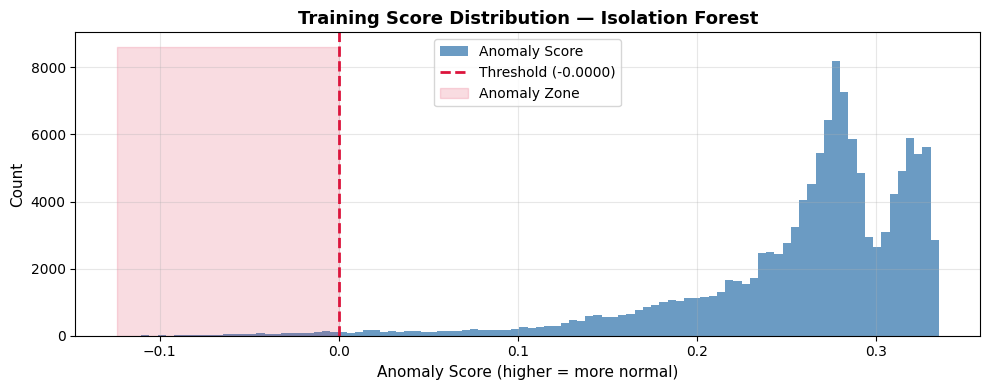

📁 Saved → results/training_score_distribution.png


In [54]:
# ── Training score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_scores, bins=100, color='steelblue', alpha=0.8, edgecolor='none', label='Anomaly Score')
ax.axvline(THRESHOLD, color='crimson', linewidth=2, linestyle='--', label=f'Threshold ({THRESHOLD:.4f})')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1],
                  train_scores.min(), THRESHOLD,
                  alpha=0.15, color='crimson', label='Anomaly Zone')
ax.set_xlabel('Anomaly Score (higher = more normal)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Training Score Distribution — Isolation Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/training_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/training_score_distribution.png")

In [55]:
# ── Per-node score distribution on training data
feat_df_scored = normal.copy()
feat_df_scored['anomaly_score'] = train_scores
feat_df_scored['is_anomaly']    = (train_scores < THRESHOLD).astype(int)

node_summary = feat_df_scored.groupby('node').agg(
    n_samples   = ('anomaly_score', 'count'),
    mean_score  = ('anomaly_score', 'mean'),
    min_score   = ('anomaly_score', 'min'),
    n_anomalies = ('is_anomaly', 'sum')
).round(4)
node_summary['anomaly_pct'] = (node_summary['n_anomalies'] / node_summary['n_samples'] * 100).round(2)

print("📡 Per-node training score summary:")
display(node_summary)

📡 Per-node training score summary:


,n_samples,mean_score,min_score,n_anomalies,anomaly_pct
node,,,,,
bottleneck,5356,0.2478,0.0552,0,0.00
c1,11563,0.2655,-0.0955,89,0.77
c2,11556,0.2692,-0.1042,83,0.72
c3,11564,0.2708,-0.0864,49,0.42
c4,5680,0.2982,-0.0308,29,0.51
c5,5682,0.2988,-0.0311,29,0.51
c6,5681,0.2991,-0.0326,30,0.53
p1,11559,0.2692,-0.1060,34,0.29
p2,11555,0.2733,-0.0854,30,0.26


In [56]:
MODEL_PATH     = os.path.join(MODEL_DIR, "ndn_isolation_forest.joblib")
THRESHOLD_PATH = os.path.join(MODEL_DIR, "ndn_threshold.json")
FEATURES_PATH  = os.path.join(MODEL_DIR, "feature_cols.json")

# Save pipeline (scaler + model)
joblib.dump(pipeline, MODEL_PATH)
print(f"✅ Pipeline saved → {MODEL_PATH}")

# Save threshold
meta = {
    'threshold': float(THRESHOLD),
    'contamination': IF_CONTAMINATION,
    'anomaly_percentile': ANOMALY_PERCENTILE,
    'n_estimators': IF_N_ESTIMATORS,
    'trained_on_nodes': sorted(normal['node'].unique().tolist()),
    'n_training_samples': int(len(model)),
    'trained_at': datetime.utcnow().isoformat()
}
with open(THRESHOLD_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"✅ Threshold metadata saved → {THRESHOLD_PATH}")

# Save feature column order (critical for inference)
with open(FEATURES_PATH, 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f"✅ Feature columns saved → {FEATURES_PATH}")

✅ Pipeline saved → ../Models/ndn_isolation_forest.joblib
✅ Threshold metadata saved → ../Models/ndn_threshold.json
✅ Feature columns saved → ../Models/feature_cols.json


In [57]:
def load_model(model_dir: str = MODEL_DIR):
    """
    Load the saved pipeline, threshold, and feature columns.
    Returns:
        pipeline   : sklearn Pipeline (scaler + iforest)
        threshold  : float
        feat_cols  : list[str]
        meta       : dict with training metadata
    """
    pipeline  = joblib.load(os.path.join(model_dir, "ndn_isolation_forest.joblib"))
    with open(os.path.join(model_dir, "ndn_threshold.json")) as f:
        meta = json.load(f)
    with open(os.path.join(model_dir, "feature_cols.json")) as f:
        feat_cols = json.load(f)
    
    threshold = meta['threshold']
    print(f"✅ Model loaded from '{model_dir}'")
    print(f"   Threshold         : {threshold:.6f}")
    print(f"   Trained on nodes  : {meta['trained_on_nodes']}")
    print(f"   Training samples  : {meta['n_training_samples']:,}")
    print(f"   Feature columns   : {feat_cols}")
    return pipeline, threshold, feat_cols, meta


loaded_pipeline, loaded_threshold, loaded_feat_cols, loaded_meta = load_model()

# Quick sanity check
test_scores = loaded_pipeline.decision_function(model[:5])
orig_scores = pipeline.decision_function(model[:5])
assert np.allclose(test_scores, orig_scores), "Loaded model doesn't match original!"
print("\n🎯 Round-trip check passed — loaded model is identical.")

✅ Model loaded from '../Models'
   Threshold         : -0.000000
   Trained on nodes  : ['bottleneck', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'p1', 'p2', 'r1', 'r2', 'r3', 'r4']
   Training samples  : 126,423
   Feature columns   : ['pit_size', 'pit_growth_rate', 'cs_size', 'cache_hit_ratio', 'satisfaction_ratio', 'unsatisfied_ratio', 'in_interests_rate', 'out_interests_rate', 'in_data_rate', 'nack_rate']

🎯 Round-trip check passed — loaded model is identical.


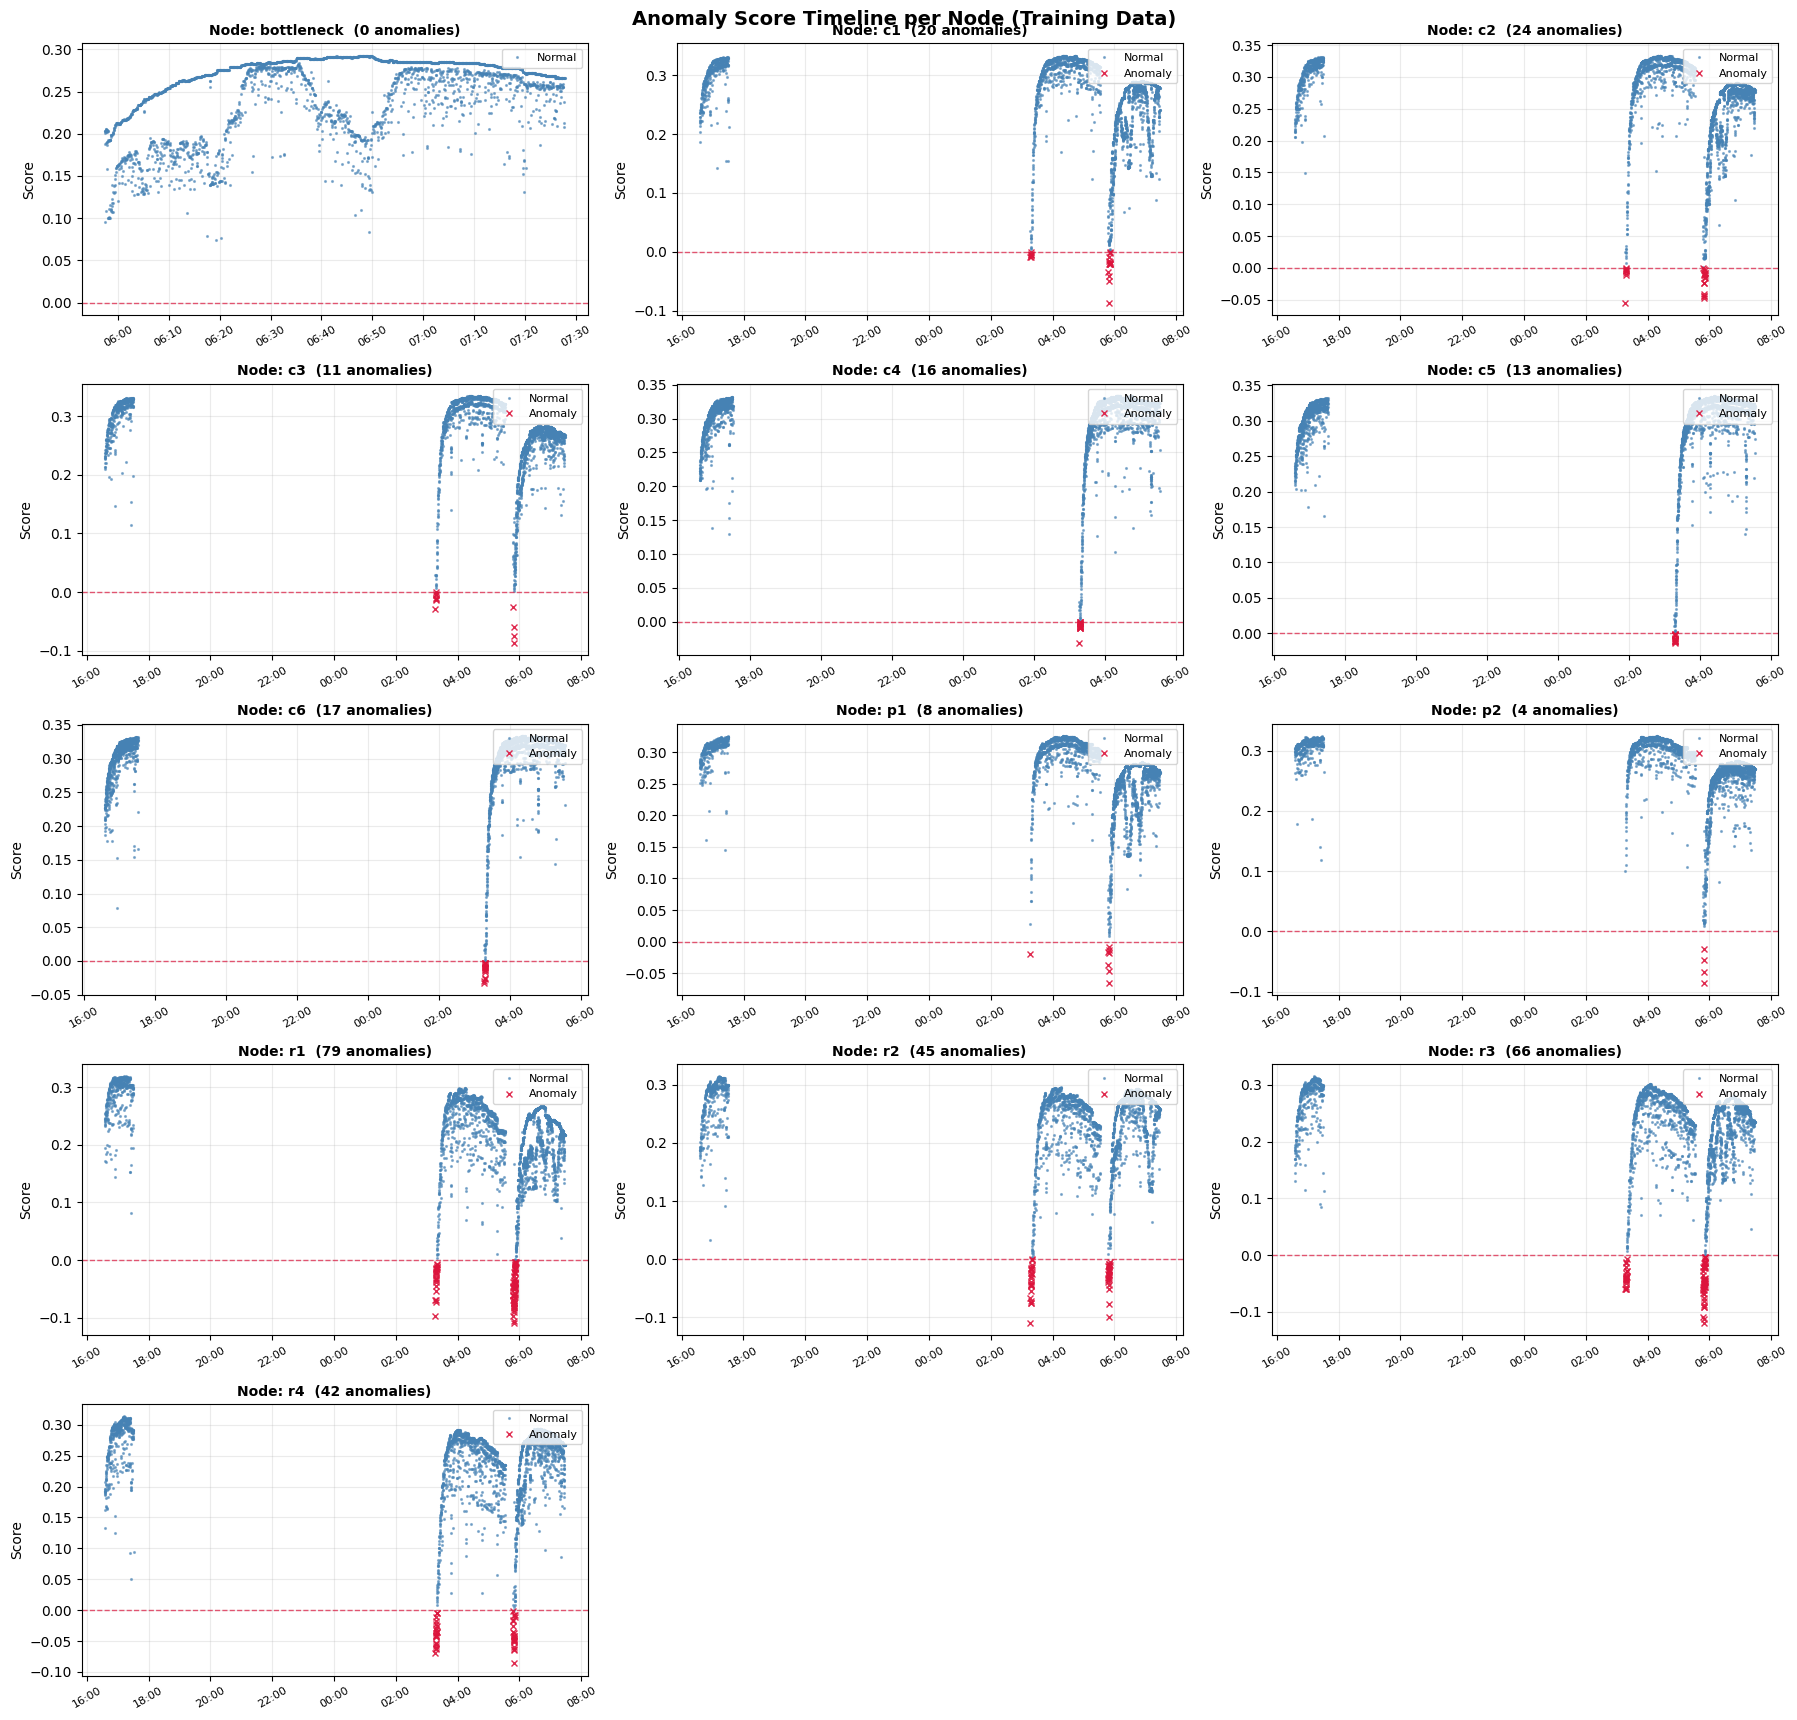

Saved -> per_node_anomaly_timeline.png


In [58]:
# ── Per-node anomaly timeline plot (optimized for large datasets)
TIMELINE_MAX_POINTS_PER_NODE = 3000   # Reduce if plotting is still slow
TIMELINE_MAX_NODES = None             # Set an int to limit nodes for quick preview

timeline_df = feat_df_scored.copy()

# Robust datetime handling for pandas StringDtype/object columns.
if 'timestamp' not in timeline_df.columns:
    raise KeyError("Column 'timestamp' is missing in feat_df_scored.")

if not pd.api.types.is_datetime64_any_dtype(timeline_df['timestamp']):
    timeline_df['timestamp'] = pd.to_datetime(timeline_df['timestamp'], errors='coerce')

timeline_df = timeline_df.dropna(subset=['timestamp'])

nodes = sorted(timeline_df['node'].unique())
if TIMELINE_MAX_NODES is not None:
    nodes = nodes[:TIMELINE_MAX_NODES]

n_nodes = len(nodes)
if n_nodes == 0:
    raise ValueError("No valid timestamp rows found for timeline plot.")

n_cols = min(3, n_nodes)
n_rows = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows), squeeze=False)

for idx, node_name in enumerate(nodes):
    ax = axes[idx // n_cols][idx % n_cols]
    grp = timeline_df[timeline_df['node'] == node_name].sort_values('timestamp')

    # Downsample very large node timelines for faster rendering.
    if len(grp) > TIMELINE_MAX_POINTS_PER_NODE:
        grp = grp.iloc[np.linspace(0, len(grp) - 1, TIMELINE_MAX_POINTS_PER_NODE, dtype=int)]

    normal_points = grp[grp['is_anomaly'] == 0]
    anomaly_points = grp[grp['is_anomaly'] == 1]

    ax.plot(normal_points['timestamp'], normal_points['anomaly_score'], '.', color='steelblue', markersize=2.5, alpha=0.55, label='Normal')
    if len(anomaly_points) > 0:
        ax.plot(anomaly_points['timestamp'], anomaly_points['anomaly_score'], 'x', color='crimson', markersize=5, alpha=0.9, label='Anomaly')

    ax.axhline(THRESHOLD, color='crimson', linewidth=1.0, linestyle='--', alpha=0.7)
    ax.set_title(f'Node: {node_name}  ({len(anomaly_points)} anomalies)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='upper right')

# Hide unused subplots
for idx in range(n_nodes, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

plt.suptitle('Anomaly Score Timeline per Node (Training Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/per_node_anomaly_timeline.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved -> per_node_anomaly_timeline.png")

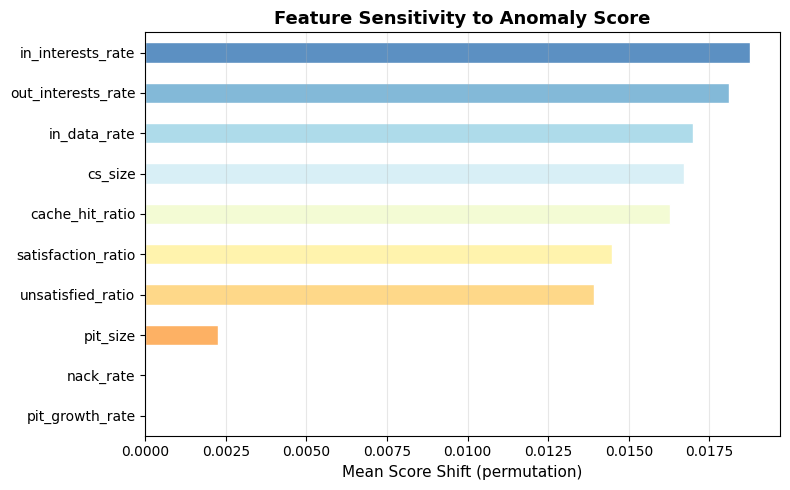

📁 Saved → results/feature_importance.png


In [59]:
# ── Feature importance proxy: mean absolute SHAP-like impact
# (We use permutation sensitivity as IF doesn't give feature importances natively)
base_scores = pipeline.decision_function(model)
importance = {}

for i, col in enumerate(FEATURE_COLS):
    X_perm = model.copy()
    np.random.shuffle(X_perm[:, i])
    perm_scores = pipeline.decision_function(X_perm)
    importance[col] = np.abs(base_scores - perm_scores).mean()

imp_series = pd.Series(importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.RdYlBu(np.linspace(0.15, 0.85, len(imp_series)))
imp_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Mean Score Shift (permutation)', fontsize=11)
ax.set_title('Feature Sensitivity to Anomaly Score', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Saved → results/feature_importance.png")

In [60]:
# Save scored training data as CSV for reference
out_csv = os.path.join(RESULTS_DIR, "training_scored.csv")
feat_df_scored.to_csv(out_csv, index=False)
print(f"📁 Scored training data saved → {out_csv}")

📁 Scored training data saved → ../Results/training_scored.csv


In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
# MULTI-DATASET ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

def analyze_dataset(df: pd.DataFrame, dataset_name: str, pipeline, threshold, feat_cols):
    """
    Analyze a dataset using the trained model.

    Returns:
        analysis_dict : dict with detailed results
        scored_df : DataFrame with scores and predictions
        node_summary : per-node statistics
    """
    print(f"\nAnalyzing '{dataset_name}' dataset...")
    print(f"   Samples: {len(df)}")

    # Extract features
    X = df[feat_cols].values

    # Score using trained model
    scores = pipeline.decision_function(X)
    predictions = (scores < threshold).astype(int)  # 1 = anomaly

    # Create scored dataframe
    scored_df = df.copy()
    scored_df['anomaly_score'] = scores
    scored_df['is_anomaly'] = predictions

    # Per-node statistics
    node_summary = scored_df.groupby('node').agg(
        n_samples=('anomaly_score', 'count'),
        mean_score=('anomaly_score', 'mean'),
        std_score=('anomaly_score', 'std'),
        min_score=('anomaly_score', 'min'),
        max_score=('anomaly_score', 'max'),
        n_anomalies=('is_anomaly', 'sum')
    ).round(4)

    node_summary['anomaly_pct'] = (node_summary['n_anomalies'] / node_summary['n_samples'] * 100).round(2)

    # Overall statistics
    analysis_dict = {
        'dataset_name': dataset_name,
        'n_samples': len(df),
        'n_nodes': df['node'].nunique(),
        'n_anomalies': int(predictions.sum()),
        'anomaly_pct': float(predictions.sum() / len(df) * 100),
        'mean_score': float(scores.mean()),
        'std_score': float(scores.std()),
        'min_score': float(scores.min()),
        'max_score': float(scores.max()),
        'threshold': float(threshold)
    }

    print(f"   Total anomalies: {analysis_dict['n_anomalies']} ({analysis_dict['anomaly_pct']:.2f}%)")

    return analysis_dict, scored_df, node_summary


# Analyze all datasets
DATASET_ORDER = ['normal', 'anomaly', 'mixed', 'cp_attack', 'ifa_attack']
datasets = {
    'normal': normal,
    'anomaly': anomaly,
    'mixed': mixed,
    'cp_attack': cp_attack,
    'ifa_attack': ifa_attack
}

results = {}
all_analyses = []

for ds_name in DATASET_ORDER:
    ds_df = datasets[ds_name]
    analysis, scored, node_stats = analyze_dataset(ds_df, ds_name, pipeline, THRESHOLD, FEATURE_COLS)
    results[ds_name] = {
        'analysis': analysis,
        'scored_df': scored,
        'node_stats': node_stats
    }
    all_analyses.append(analysis)
    print(f"\nPer-node summary for '{ds_name}':")
    print(node_stats)

# Create summary table
summary_df = pd.DataFrame(all_analyses)
print("\n" + "=" * 80)
print("OVERALL DATASET COMPARISON")
print("=" * 80)
display(summary_df)


Analyzing 'normal' dataset...
   Samples: 126423
   Total anomalies: 1265 (1.00%)

Per-node summary for 'normal':
            n_samples  mean_score  std_score  min_score  max_score  \
node                                                                 
bottleneck       5356      0.2478     0.0443     0.0552     0.2925   
c1              11563      0.2655     0.0677    -0.0955     0.3335   
c2              11556      0.2692     0.0656    -0.1042     0.3335   
c3              11564      0.2708     0.0611    -0.0864     0.3345   
c4               5680      0.2982     0.0513    -0.0308     0.3335   
c5               5682      0.2988     0.0516    -0.0311     0.3350   
c6               5681      0.2991     0.0515    -0.0326     0.3335   
p1              11559      0.2692     0.0541    -0.1060     0.3253   
p2              11555      0.2733     0.0500    -0.0854     0.3241   
r1              11562      0.2181     0.0740    -0.1232     0.3194   
r2              11558      0.2403     0.0639 

,dataset_name,n_samples,n_nodes,n_anomalies,anomaly_pct,mean_score,std_score,min_score,max_score,threshold
0,normal,126423,13,1265,1.000609,0.259188,0.065713,-0.124031,0.334980,-3.575495e-17
1,anomaly,36758,13,637,1.732956,0.263209,0.076848,-0.104602,0.331565,-3.575495e-17
2,mixed,163181,13,1902,1.165577,0.260094,0.068401,-0.124031,0.334980,-3.575495e-17
3,cp_attack,16225,12,361,2.224961,0.253078,0.082698,-0.104602,0.328238,-3.575495e-17
4,ifa_attack,20533,10,276,1.344178,0.271214,0.070874,-0.082939,0.331565,-3.575495e-17


In [62]:
# ─── PER-NODE ANOMALY STATISTICS TABLE FOR ALL DATASETS ───────────────────────

print("\n" + "=" * 80)
print("DETAILED PER-NODE ANALYSIS FOR ALL DATASETS")
print("=" * 80)

for ds_name in DATASET_ORDER:
    print(f"\n{ds_name.upper()} DATASET:")
    print(results[ds_name]['node_stats'].to_string())
    print()


DETAILED PER-NODE ANALYSIS FOR ALL DATASETS

NORMAL DATASET:
            n_samples  mean_score  std_score  min_score  max_score  n_anomalies  anomaly_pct
node                                                                                        
bottleneck       5356      0.2478     0.0443     0.0552     0.2925            0         0.00
c1              11563      0.2655     0.0677    -0.0955     0.3335           89         0.77
c2              11556      0.2692     0.0656    -0.1042     0.3335           83         0.72
c3              11564      0.2708     0.0611    -0.0864     0.3345           49         0.42
c4               5680      0.2982     0.0513    -0.0308     0.3335           29         0.51
c5               5682      0.2988     0.0516    -0.0311     0.3350           29         0.51
c6               5681      0.2991     0.0515    -0.0326     0.3335           30         0.53
p1              11559      0.2692     0.0541    -0.1060     0.3253           34         0.29
p2      

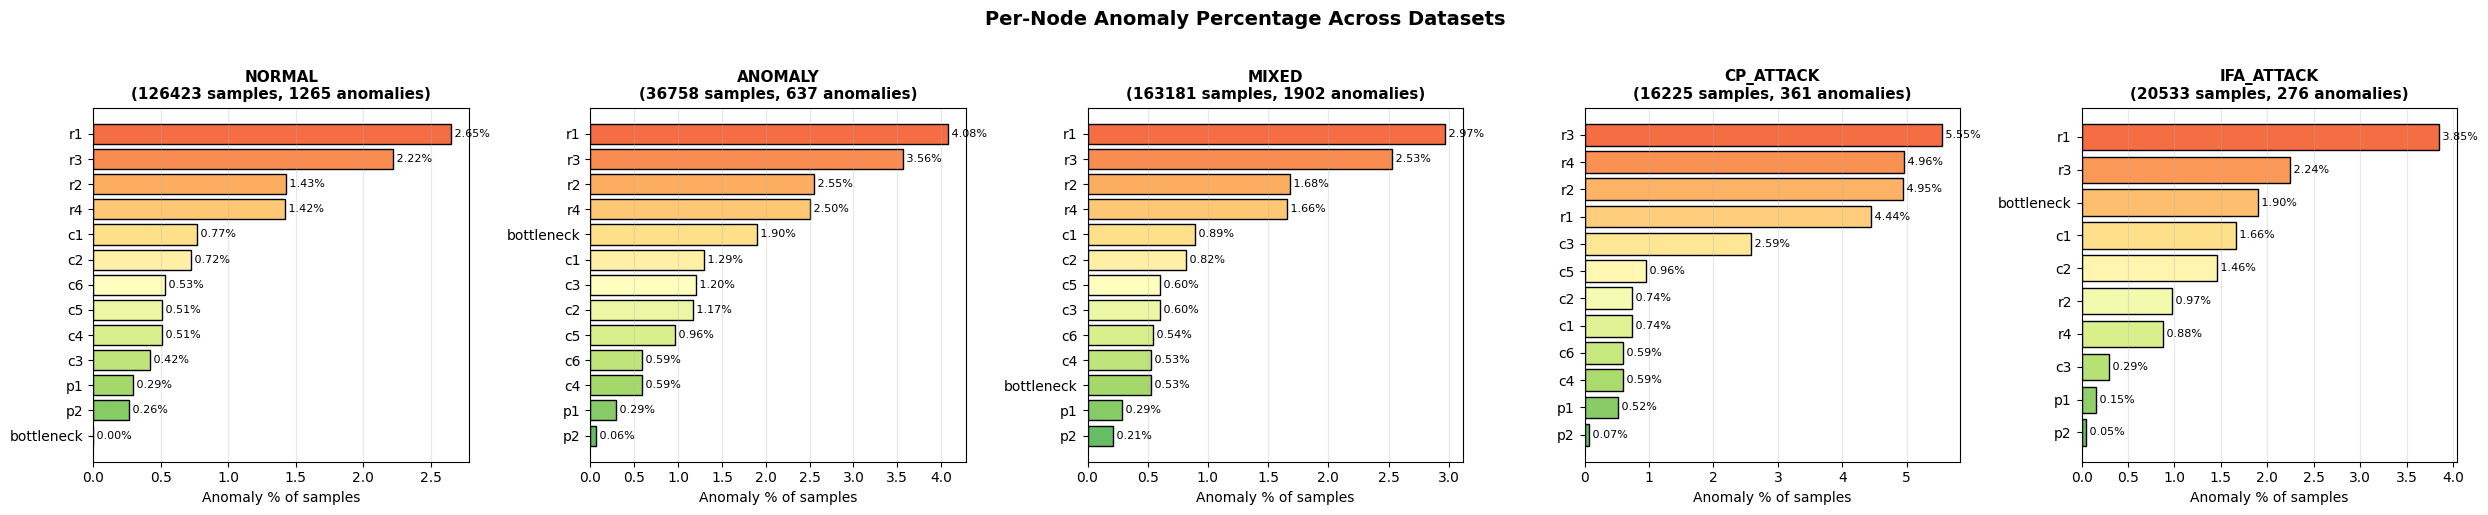

Saved -> nodewise_anomaly_pct_comparison.png


In [63]:
# ─── NODEWISE ANOMALY PERCENTAGE COMPARISON ACROSS DATASETS ────────────────────

fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(5 * len(DATASET_ORDER), 5), squeeze=False)

for idx, ds_name in enumerate(DATASET_ORDER):
    node_stats = results[ds_name]['node_stats']
    ax = axes[0, idx]

    # Sort by anomaly_pct for better visualization
    sorted_stats = node_stats.sort_values('anomaly_pct', ascending=True)

    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sorted_stats)))
    bars = ax.barh(range(len(sorted_stats)), sorted_stats['anomaly_pct'], color=colors, edgecolor='black')

    ax.set_yticks(range(len(sorted_stats)))
    ax.set_yticklabels(sorted_stats.index)
    ax.set_xlabel('Anomaly % of samples', fontsize=10)
    ax.set_title(
        f"{ds_name.upper()}\n({sorted_stats['n_samples'].sum():.0f} samples, {sorted_stats['n_anomalies'].sum():.0f} anomalies)",
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, val in enumerate(sorted_stats['anomaly_pct']):
        ax.text(val, i, f' {val:.2f}%', va='center', fontsize=8)

plt.suptitle('Per-Node Anomaly Percentage Across Datasets', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/nodewise_anomaly_pct_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> nodewise_anomaly_pct_comparison.png")

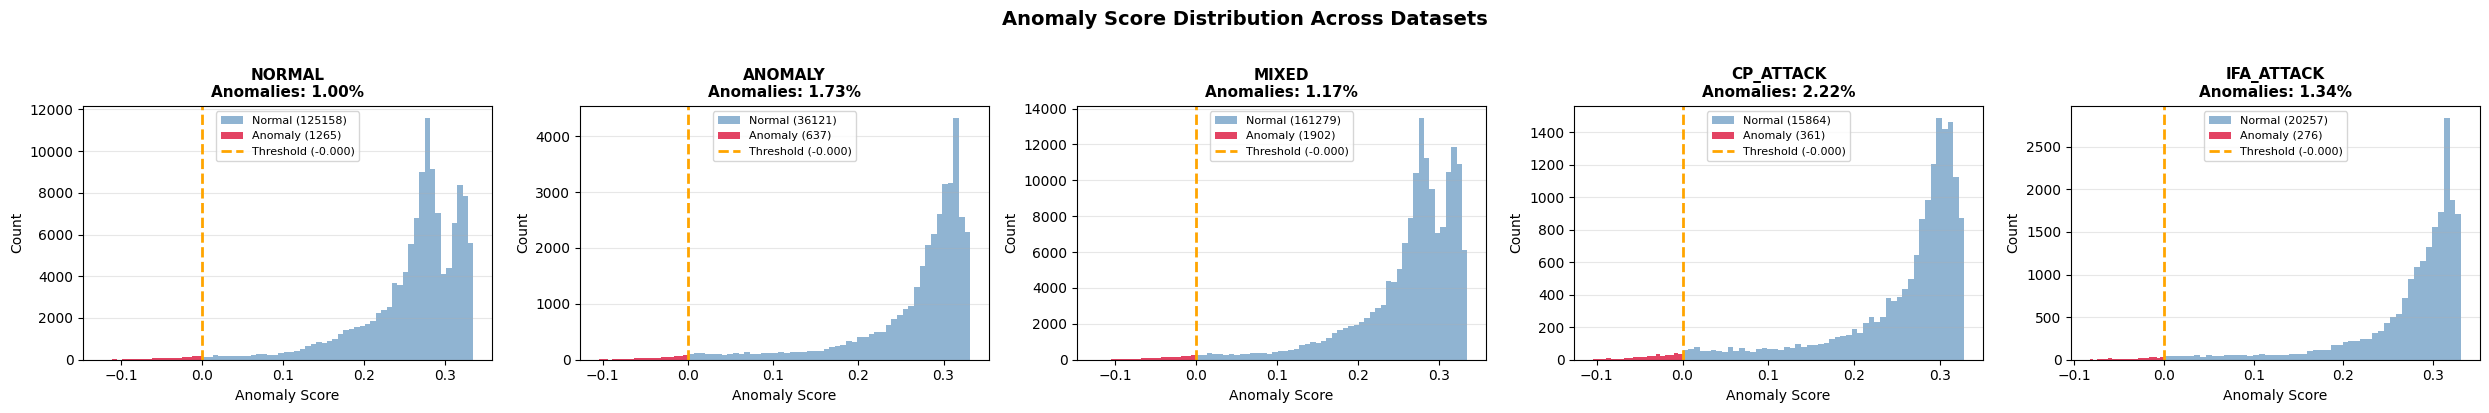

Saved -> score_distribution_comparison.png


In [64]:
# ─── ANOMALY SCORE DISTRIBUTION ACROSS DATASETS ─────────────────────────────────

fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(5 * len(DATASET_ORDER), 4), squeeze=False)

for idx, ds_name in enumerate(DATASET_ORDER):
    scored_df = results[ds_name]['scored_df']
    ax = axes[0, idx]

    anomalies = scored_df[scored_df['is_anomaly'] == 1]['anomaly_score'].values
    normal_points = scored_df[scored_df['is_anomaly'] == 0]['anomaly_score'].values

    ax.hist(normal_points, bins=50, color='steelblue', alpha=0.6, label=f'Normal ({len(normal_points)})', edgecolor='none')
    if len(anomalies) > 0:
        ax.hist(anomalies, bins=20, color='crimson', alpha=0.8, label=f'Anomaly ({len(anomalies)})', edgecolor='none')

    ax.axvline(THRESHOLD, color='orange', linewidth=2.0, linestyle='--', label=f'Threshold ({THRESHOLD:.3f})')
    ax.set_xlabel('Anomaly Score', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(
        f"{ds_name.upper()}\nAnomalies: {(scored_df['is_anomaly'].sum() / len(scored_df) * 100):.2f}%",
        fontsize=11,
        fontweight='bold'
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Anomaly Score Distribution Across Datasets', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/score_distribution_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> score_distribution_comparison.png")

Computing feature importance for each dataset...
Done: normal
Done: anomaly
Done: mixed
Done: cp_attack
Done: ifa_attack


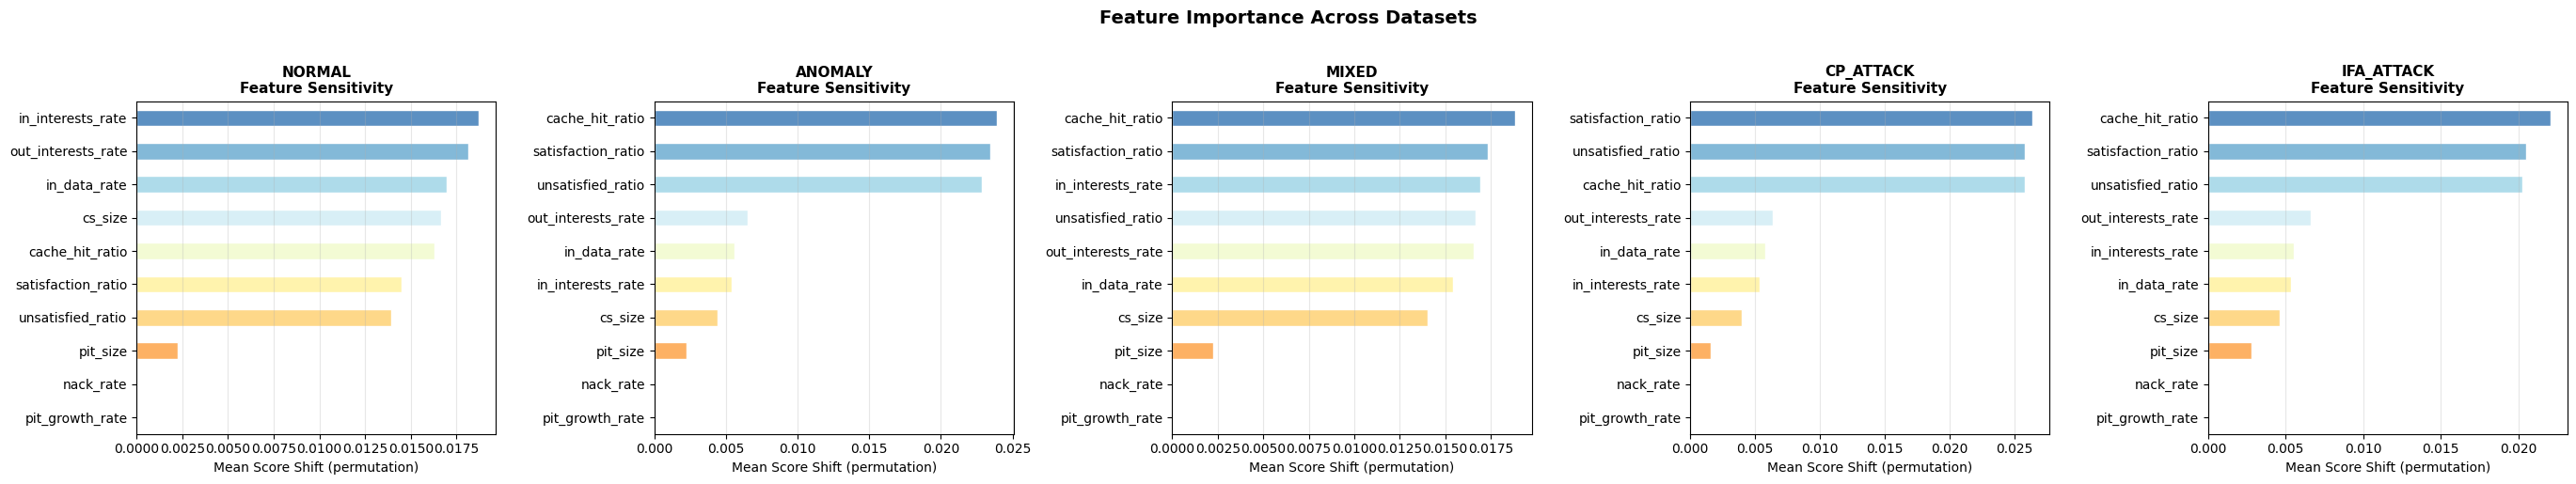

Saved -> feature_importance_comparison.png


In [65]:
# ─── FEATURE IMPORTANCE ANALYSIS FOR EACH DATASET ────────────────────────────────

def compute_feature_importance(X: np.ndarray, pipeline, feat_cols, n_repeats: int = 2):
    """Compute permutation-based feature importance."""
    base_scores = pipeline.decision_function(X)
    importance = {}

    for i, col in enumerate(feat_cols):
        perm_importances = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            np.random.shuffle(X_perm[:, i])
            perm_scores = pipeline.decision_function(X_perm)
            perm_importances.append(np.abs(base_scores - perm_scores).mean())
        importance[col] = float(np.mean(perm_importances))

    return importance

print("Computing feature importance for each dataset...")

feature_importance_by_dataset = {}

for ds_name in DATASET_ORDER:
    scored_df = results[ds_name]['scored_df']
    X = scored_df[FEATURE_COLS].values
    importance = compute_feature_importance(X, pipeline, FEATURE_COLS, n_repeats=2)
    feature_importance_by_dataset[ds_name] = pd.Series(importance).sort_values(ascending=True)
    print(f"Done: {ds_name}")

# Plot feature importance for all datasets
fig, axes = plt.subplots(1, len(DATASET_ORDER), figsize=(5.5 * len(DATASET_ORDER), 5), squeeze=False)

for idx, ds_name in enumerate(DATASET_ORDER):
    imp_series = feature_importance_by_dataset[ds_name]
    ax = axes[0, idx]

    colors = plt.cm.RdYlBu(np.linspace(0.15, 0.85, len(imp_series)))
    imp_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=1.0)

    ax.set_xlabel('Mean Score Shift (permutation)', fontsize=10)
    ax.set_title(f'{ds_name.upper()}\nFeature Sensitivity', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Across Datasets', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/feature_importance_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> feature_importance_comparison.png")

In [66]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE ALL RESULTS TO CSV FILES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("SAVING ALL RESULTS TO CSV FILES")
print("=" * 80)

# Create a subdirectory for detailed results
detailed_results_dir = os.path.join(RESULTS_DIR, "detailed_analysis")
Path(detailed_results_dir).mkdir(parents=True, exist_ok=True)

saved_files = []

# 1. Save overall dataset summary
summary_path = os.path.join(RESULTS_DIR, "dataset_comparison_summary.csv")
summary_df.to_csv(summary_path, index=False)
saved_files.append(("Dataset Comparison Summary", summary_path))

# 2. Save per-node statistics for each dataset
for ds_name in DATASET_ORDER:
    node_stats = results[ds_name]['node_stats']
    node_stats_path = os.path.join(detailed_results_dir, f"{ds_name}_nodewise_stats.csv")
    node_stats.to_csv(node_stats_path)
    saved_files.append((f"{ds_name.upper()} - Per-node Statistics", node_stats_path))

# 3. Save scored datasets (with anomaly scores and predictions)
for ds_name in DATASET_ORDER:
    scored_df = results[ds_name]['scored_df']
    scored_path = os.path.join(detailed_results_dir, f"{ds_name}_scored.csv")
    scored_df.to_csv(scored_path, index=False)
    saved_files.append((f"{ds_name.upper()} - Scored Data", scored_path))

# 4. Save feature importance for each dataset
for ds_name in DATASET_ORDER:
    imp_series = feature_importance_by_dataset[ds_name]
    imp_df = pd.DataFrame({
        'feature': imp_series.index,
        'importance_score': imp_series.values
    }).sort_values('importance_score', ascending=False)

    imp_path = os.path.join(detailed_results_dir, f"{ds_name}_feature_importance.csv")
    imp_df.to_csv(imp_path, index=False)
    saved_files.append((f"{ds_name.upper()} - Feature Importance", imp_path))

# 5. Save training metadata
metadata_path = os.path.join(RESULTS_DIR, "training_metadata.json")
training_metadata = {
    'model_type': 'Isolation Forest',
    'n_estimators': IF_N_ESTIMATORS,
    'contamination': IF_CONTAMINATION,
    'threshold': float(THRESHOLD),
    'anomaly_percentile': ANOMALY_PERCENTILE,
    'feature_columns': FEATURE_COLS,
    'trained_on_nodes': sorted(normal['node'].unique().tolist()),
    'training_samples': int(len(normal)),
    'max_samples': IF_MAX_SAMPLES,
    'random_state': IF_RANDOM_STATE,
    'trained_at': datetime.utcnow().isoformat()
}
with open(metadata_path, 'w') as f:
    json.dump(training_metadata, f, indent=2)
saved_files.append(("Training Metadata", metadata_path))

# 6. Save cross-dataset comparison table
comparison_table = []
for ds_name in DATASET_ORDER:
    node_stats = results[ds_name]['node_stats']
    for node_name in node_stats.index:
        comparison_table.append({
            'dataset': ds_name,
            'node': node_name,
            'n_samples': int(node_stats.loc[node_name, 'n_samples']),
            'n_anomalies': int(node_stats.loc[node_name, 'n_anomalies']),
            'anomaly_pct': float(node_stats.loc[node_name, 'anomaly_pct']),
            'mean_score': float(node_stats.loc[node_name, 'mean_score']),
            'std_score': float(node_stats.loc[node_name, 'std_score']),
            'min_score': float(node_stats.loc[node_name, 'min_score']),
            'max_score': float(node_stats.loc[node_name, 'max_score'])
        })

comparison_df = pd.DataFrame(comparison_table)
comparison_path = os.path.join(RESULTS_DIR, "cross_dataset_nodewise_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)
saved_files.append(("Cross-Dataset Node Comparison", comparison_path))

# Print summary
print("\nFILES SAVED:\n")
for idx, (desc, path) in enumerate(saved_files, 1):
    rel_path = os.path.relpath(path, os.getcwd())
    print(f"{idx}. {desc}")
    print(f"   -> {rel_path}\n")

print(f"All files saved to: {os.path.relpath(RESULTS_DIR, os.getcwd())}/")


SAVING ALL RESULTS TO CSV FILES

FILES SAVED:

1. Dataset Comparison Summary
   -> ../Results/dataset_comparison_summary.csv

2. NORMAL - Per-node Statistics
   -> ../Results/detailed_analysis/normal_nodewise_stats.csv

3. ANOMALY - Per-node Statistics
   -> ../Results/detailed_analysis/anomaly_nodewise_stats.csv

4. MIXED - Per-node Statistics
   -> ../Results/detailed_analysis/mixed_nodewise_stats.csv

5. CP_ATTACK - Per-node Statistics
   -> ../Results/detailed_analysis/cp_attack_nodewise_stats.csv

6. IFA_ATTACK - Per-node Statistics
   -> ../Results/detailed_analysis/ifa_attack_nodewise_stats.csv

7. NORMAL - Scored Data
   -> ../Results/detailed_analysis/normal_scored.csv

8. ANOMALY - Scored Data
   -> ../Results/detailed_analysis/anomaly_scored.csv

9. MIXED - Scored Data
   -> ../Results/detailed_analysis/mixed_scored.csv

10. CP_ATTACK - Scored Data
   -> ../Results/detailed_analysis/cp_attack_scored.csv

11. IFA_ATTACK - Scored Data
   -> ../Results/detailed_analysis/ifa_at

In [67]:
# ─── ANALYSIS SUMMARY & INSIGHTS ──────────────────────────────────────────────────

print("\n" + "=" * 80)
print("ANALYSIS SUMMARY")
print("=" * 80)

summary_report = f"""
MODEL PERFORMANCE ACROSS DATASETS
{'-' * 78}

Model Configuration:
  - Type: Isolation Forest
  - n_estimators: {IF_N_ESTIMATORS}
  - Contamination: {IF_CONTAMINATION}
  - Auto-threshold (p{ANOMALY_PERCENTILE}): {THRESHOLD:.6f}
  - Features: {len(FEATURE_COLS)}

Dataset Statistics:
"""

for ds_name in DATASET_ORDER:
    ana = results[ds_name]['analysis']
    summary_report += f"""
{ds_name.upper()}:
  - Samples: {ana['n_samples']:,}
  - Nodes: {ana['n_nodes']}
  - Anomalies detected: {ana['n_anomalies']} ({ana['anomaly_pct']:.2f}%)
  - Mean anomaly score: {ana['mean_score']:.4f}
  - Score range: [{ana['min_score']:.4f}, {ana['max_score']:.4f}]
"""

summary_report += """

Saved Artifacts:
  - dataset_comparison_summary.csv
  - detailed_analysis/*_scored.csv
  - detailed_analysis/*_nodewise_stats.csv
  - detailed_analysis/*_feature_importance.csv
  - cross_dataset_nodewise_comparison.csv
  - training_metadata.json
"""

print(summary_report)

print("\n" + "=" * 80)
print("TOP 5 ANOMALOUS NODES PER DATASET")
print("=" * 80)

for ds_name in DATASET_ORDER:
    node_stats = results[ds_name]['node_stats'].sort_values('anomaly_pct', ascending=False)
    print(f"\n{ds_name.upper()}:")
    print(node_stats[['anomaly_pct', 'n_anomalies', 'n_samples']].head().to_string())


ANALYSIS SUMMARY

MODEL PERFORMANCE ACROSS DATASETS
------------------------------------------------------------------------------

Model Configuration:
  - Type: Isolation Forest
  - n_estimators: 200
  - Contamination: 0.01
  - Auto-threshold (p1): -0.000000
  - Features: 10

Dataset Statistics:

NORMAL:
  - Samples: 126,423
  - Nodes: 13
  - Anomalies detected: 1265 (1.00%)
  - Mean anomaly score: 0.2592
  - Score range: [-0.1240, 0.3350]

ANOMALY:
  - Samples: 36,758
  - Nodes: 13
  - Anomalies detected: 637 (1.73%)
  - Mean anomaly score: 0.2632
  - Score range: [-0.1046, 0.3316]

MIXED:
  - Samples: 163,181
  - Nodes: 13
  - Anomalies detected: 1902 (1.17%)
  - Mean anomaly score: 0.2601
  - Score range: [-0.1240, 0.3350]

CP_ATTACK:
  - Samples: 16,225
  - Nodes: 12
  - Anomalies detected: 361 (2.22%)
  - Mean anomaly score: 0.2531
  - Score range: [-0.1046, 0.3282]

IFA_ATTACK:
  - Samples: 20,533
  - Nodes: 10
  - Anomalies detected: 276 (1.34%)
  - Mean anomaly score: 0.2712

### REAL TIME MONITORING

In [3]:
# Real-time inference engine (stream simulation)

# --------- Safety: load model artifacts if training cells were not run ---------
if 'pipeline' not in globals() or 'THRESHOLD' not in globals() or 'FEATURE_COLS' not in globals():
    if 'load_model' not in globals():
        def load_model(model_dir: str = MODEL_DIR):
            pipeline_local = joblib.load(os.path.join(model_dir, "ndn_isolation_forest.joblib"))
            with open(os.path.join(model_dir, "ndn_threshold.json")) as f:
                meta_local = json.load(f)
            with open(os.path.join(model_dir, "feature_cols.json")) as f:
                feat_cols_local = json.load(f)
            return pipeline_local, meta_local['threshold'], feat_cols_local, meta_local

    pipeline, THRESHOLD, FEATURE_COLS, loaded_meta = load_model(MODEL_DIR)
    print("Model loaded for real-time inference.")


# --------- Safety: load datasets if not available in memory ---------
def _load_datasets_if_needed(data_dir: str):
    ds_map = {}
    ds_files = {
        'normal': 'normal_traffic_features.csv',
        'anomaly': 'anomaly_traffic_features.csv',
        'mixed': 'ndn_mixed_normal_anomaly_features.csv',
        'cp_attack': 'cp_attack_features.csv',
        'ifa_attack': 'ifa_attack_features.csv'
    }

    for name, fname in ds_files.items():
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            ds_map[name] = globals()[name].copy()
        else:
            ds_map[name] = pd.read_csv(f"{data_dir}/{fname}")
    return ds_map


datasets_rt = _load_datasets_if_needed(DATASETS_DIR)


# --------- Real-time streaming simulator ---------
def run_realtime_inference(
    source_df: pd.DataFrame,
    dataset_name: str,
    model_pipeline,
    threshold: float,
    feat_cols,
    alert_consecutive: int = 3,
    alert_window: int = 50,
    alert_rate_pct: float = 5.0
):
    """
    Simulate real-time inference row by row and produce alert events.

    Alert rules:
      1) consecutive anomalies >= alert_consecutive
      2) anomaly rate in last alert_window points >= alert_rate_pct
    """
    rt_df = source_df.copy()

    if 'timestamp' in rt_df.columns:
        rt_df['timestamp'] = pd.to_datetime(rt_df['timestamp'], errors='coerce')
        rt_df = rt_df.sort_values(['node', 'timestamp']) if 'node' in rt_df.columns else rt_df.sort_values('timestamp')
    else:
        rt_df['timestamp'] = pd.NaT

    # Score in one vectorized pass; emit stream state row-wise.
    X = rt_df[feat_cols].values
    scores = model_pipeline.decision_function(X)
    preds = (scores < threshold).astype(int)

    rt_df['anomaly_score'] = scores
    rt_df['is_anomaly'] = preds

    events = []
    stream_rows = []

    for node_name, grp in rt_df.groupby('node', sort=False):
        consecutive = 0
        recent = deque(maxlen=alert_window)

        for _, row in grp.iterrows():
            is_anom = int(row['is_anomaly'])
            consecutive = consecutive + 1 if is_anom == 1 else 0
            recent.append(is_anom)

            rate_pct = (sum(recent) / len(recent) * 100.0) if len(recent) > 0 else 0.0

            alert = False
            reason = None
            if consecutive >= alert_consecutive:
                alert = True
                reason = f"consecutive_anomalies>={alert_consecutive}"
            elif len(recent) == alert_window and rate_pct >= alert_rate_pct:
                alert = True
                reason = f"window_anomaly_rate>={alert_rate_pct}%"

            stream_rows.append({
                'dataset': dataset_name,
                'node': node_name,
                'timestamp': row['timestamp'],
                'anomaly_score': float(row['anomaly_score']),
                'is_anomaly': is_anom,
                'consecutive_anomalies': consecutive,
                'window_anomaly_rate_pct': round(rate_pct, 3),
                'alert': int(alert),
                'alert_reason': reason if reason else ''
            })

            if alert:
                events.append({
                    'dataset': dataset_name,
                    'node': node_name,
                    'timestamp': row['timestamp'],
                    'anomaly_score': float(row['anomaly_score']),
                    'window_anomaly_rate_pct': round(rate_pct, 3),
                    'alert_reason': reason
                })

    stream_df = pd.DataFrame(stream_rows)
    events_df = pd.DataFrame(events)

    return rt_df, stream_df, events_df


# --------- Run realtime simulation on selected dataset ---------
RT_DATASET = 'cp_attack'  # chosen for focused monitoring analysis
rt_input_df = datasets_rt[RT_DATASET]

rt_scored_df, rt_stream_df, rt_alerts_df = run_realtime_inference(
    source_df=rt_input_df,
    dataset_name=RT_DATASET,
    model_pipeline=pipeline,
    threshold=THRESHOLD,
    feat_cols=FEATURE_COLS,
    alert_consecutive=3,
    alert_window=50,
    alert_rate_pct=5.0
)

# Save outputs
realtime_dir = os.path.join(RESULTS_DIR, "realtime")
Path(realtime_dir).mkdir(parents=True, exist_ok=True)

rt_scored_path = os.path.join(realtime_dir, f"{RT_DATASET}_realtime_scored.csv")
rt_stream_path = os.path.join(realtime_dir, f"{RT_DATASET}_realtime_stream.csv")
rt_alerts_path = os.path.join(realtime_dir, f"{RT_DATASET}_realtime_alerts.csv")

rt_scored_df.to_csv(rt_scored_path, index=False)
rt_stream_df.to_csv(rt_stream_path, index=False)
rt_alerts_df.to_csv(rt_alerts_path, index=False)

print("Realtime inference completed.")
print(f"Dataset: {RT_DATASET}")
print(f"Rows processed: {len(rt_stream_df):,}")
print(f"Predicted anomalies: {int(rt_stream_df['is_anomaly'].sum()):,}")
print(f"Generated alerts: {len(rt_alerts_df):,}")
print(f"Saved: {rt_scored_path}")
print(f"Saved: {rt_stream_path}")
print(f"Saved: {rt_alerts_path}")

Model loaded for real-time inference.
Realtime inference completed.
Dataset: cp_attack
Rows processed: 16,225
Predicted anomalies: 361
Generated alerts: 679
Saved: ../Results/realtime/cp_attack_realtime_scored.csv
Saved: ../Results/realtime/cp_attack_realtime_stream.csv
Saved: ../Results/realtime/cp_attack_realtime_alerts.csv



Realtime node summary:


,node,n_samples,n_anomalies,n_alerts,mean_score,min_score,anomaly_pct,alert_pct
10,r3,1351,75,135,0.215320,-0.103853,5.55,9.99
11,r4,1351,67,132,0.215941,-0.104602,4.96,9.77
9,r2,1353,67,130,0.220379,-0.103056,4.95,9.61
8,r1,1352,60,105,0.238744,-0.101198,4.44,7.77
2,c3,1353,35,71,0.254546,-0.051927,2.59,5.25
4,c5,1351,13,46,0.259042,-0.048318,0.96,3.40
0,c1,1354,10,15,0.270230,-0.062606,0.74,1.11
1,c2,1353,10,13,0.260842,-0.061096,0.74,0.96
3,c4,1351,8,13,0.258997,-0.055855,0.59,0.96
5,c6,1351,8,10,0.269384,-0.051182,0.59,0.74


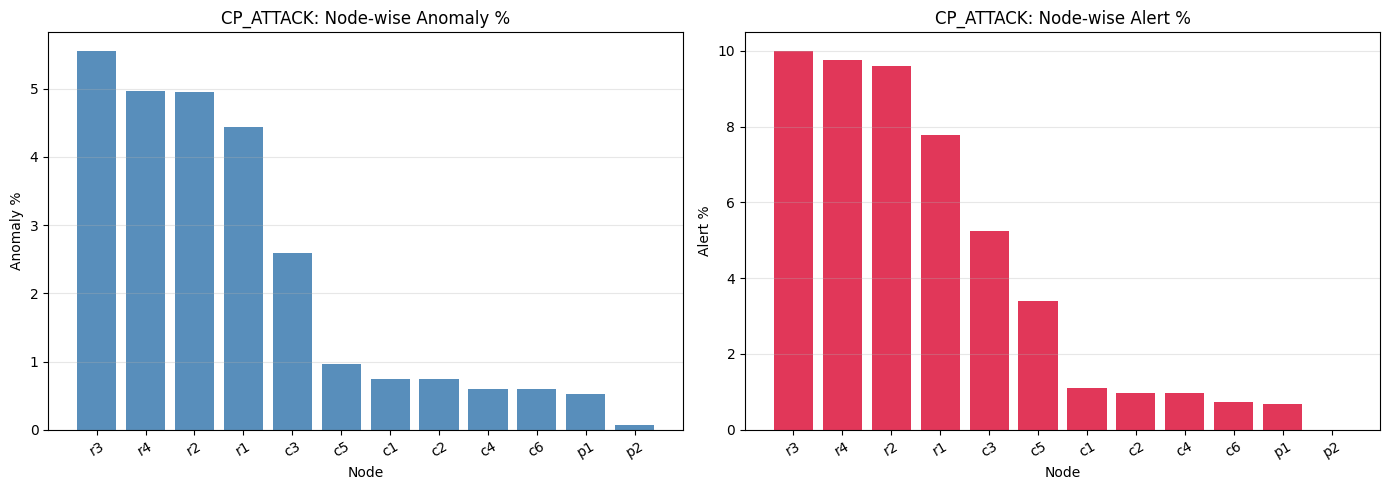

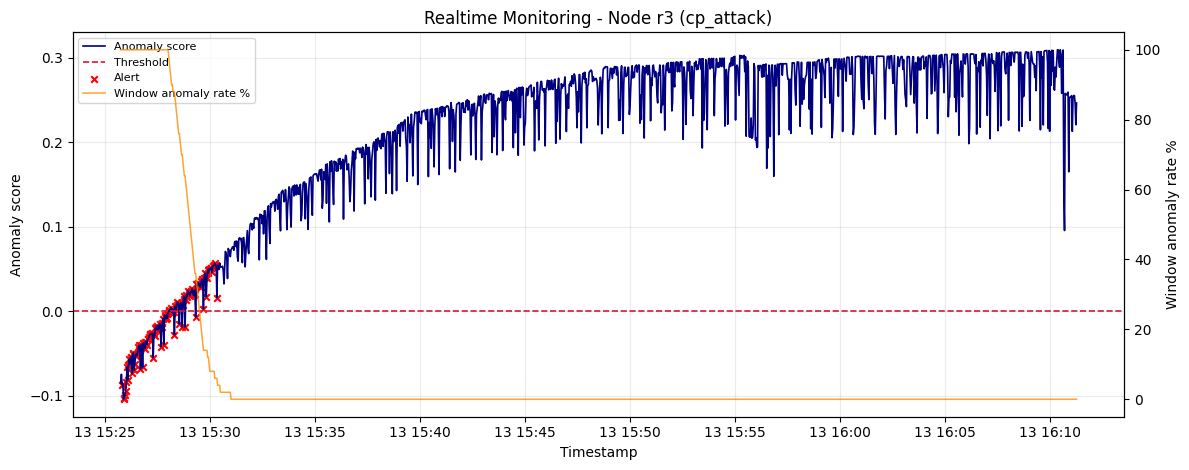

Saved: ../Results/realtime/cp_attack_realtime_node_summary.csv


In [4]:
# Focused analysis for the selected real-time dataset (cp_attack)

# Per-node alert summary
rt_node_summary = rt_stream_df.groupby('node').agg(
    n_samples=('is_anomaly', 'size'),
    n_anomalies=('is_anomaly', 'sum'),
    n_alerts=('alert', 'sum'),
    mean_score=('anomaly_score', 'mean'),
    min_score=('anomaly_score', 'min')
).reset_index()
rt_node_summary['anomaly_pct'] = (rt_node_summary['n_anomalies'] / rt_node_summary['n_samples'] * 100).round(2)
rt_node_summary['alert_pct'] = (rt_node_summary['n_alerts'] / rt_node_summary['n_samples'] * 100).round(2)

print("\nRealtime node summary:")
display(rt_node_summary.sort_values('alert_pct', ascending=False))

# Plot 1: anomaly and alert percentages by node
plot_df = rt_node_summary.sort_values('alert_pct', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(plot_df['node'], plot_df['anomaly_pct'], color='steelblue', alpha=0.9)
axes[0].set_title(f"{RT_DATASET.upper()}: Node-wise Anomaly %")
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Anomaly %')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(plot_df['node'], plot_df['alert_pct'], color='crimson', alpha=0.85)
axes[1].set_title(f"{RT_DATASET.upper()}: Node-wise Alert %")
axes[1].set_xlabel('Node')
axes[1].set_ylabel('Alert %')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/realtime/{RT_DATASET}_realtime_node_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: stream-level score and alert-rate timeline for busiest alert node
busiest_node = plot_df.iloc[0]['node'] if len(plot_df) > 0 else None
if busiest_node is not None:
    node_stream = rt_stream_df[rt_stream_df['node'] == busiest_node].copy()

    if node_stream['timestamp'].notna().any():
        x_vals = node_stream['timestamp']
        x_label = 'Timestamp'
    else:
        x_vals = np.arange(len(node_stream))
        x_label = 'Event index'

    fig, ax1 = plt.subplots(figsize=(12, 4.8))
    ax1.plot(x_vals, node_stream['anomaly_score'], color='navy', linewidth=1.2, label='Anomaly score')
    ax1.axhline(THRESHOLD, color='crimson', linestyle='--', linewidth=1.2, label='Threshold')
    ax1.set_ylabel('Anomaly score')
    ax1.set_xlabel(x_label)
    ax1.set_title(f"Realtime Monitoring - Node {busiest_node} ({RT_DATASET})")
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(x_vals, node_stream['window_anomaly_rate_pct'], color='darkorange', linewidth=1.1, alpha=0.8, label='Window anomaly rate %')
    ax2.set_ylabel('Window anomaly rate %')

    # mark alert points
    alerts_only = node_stream[node_stream['alert'] == 1]
    if len(alerts_only) > 0:
        ax1.scatter(
            alerts_only['timestamp'] if node_stream['timestamp'].notna().any() else alerts_only.index,
            alerts_only['anomaly_score'],
            color='red', s=22, marker='x', label='Alert'
        )

    # combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/realtime/{RT_DATASET}_realtime_busiest_node_timeline.png", dpi=150, bbox_inches='tight')
    plt.show()

# Save summary CSV
rt_summary_path = os.path.join(RESULTS_DIR, "realtime", f"{RT_DATASET}_realtime_node_summary.csv")
rt_node_summary.to_csv(rt_summary_path, index=False)
print(f"Saved: {rt_summary_path}")

In [5]:
# Sample anomaly alert lines with top features (first 10)

if 'rt_scored_df' not in globals():
    raise ValueError("Run the realtime inference cell first to create rt_scored_df.")

# Use scaler statistics to identify strongest per-row feature deviations.
scaler = pipeline.named_steps['scaler'] if 'pipeline' in globals() and 'scaler' in pipeline.named_steps else None
if scaler is None:
    raise ValueError("Pipeline scaler not found. Ensure pipeline has named step 'scaler'.")

means = scaler.mean_
scales = scaler.scale_
scales = np.where(scales == 0, 1.0, scales)

anomaly_rows = rt_scored_df[rt_scored_df['is_anomaly'] == 1].copy()
if 'timestamp' in anomaly_rows.columns:
    anomaly_rows['timestamp'] = pd.to_datetime(anomaly_rows['timestamp'], errors='coerce')

alert_lines = []
alert_records = []

for _, row in anomaly_rows.head(10).iterrows():
    x = row[FEATURE_COLS].values.astype(float)
    z = np.abs((x - means) / scales)
    top_idx = np.argsort(z)[-3:][::-1]
    top_features = [f"{FEATURE_COLS[i]}={x[i]:.3f}" for i in top_idx]

    node_name = row['node'] if 'node' in row else 'unknown'
    ts_val = row['timestamp'] if 'timestamp' in row and pd.notna(row['timestamp']) else 'NA'
    score_val = float(row['anomaly_score'])

    msg = (
        f"  ANOMALY on [{node_name}] @ {ts_val} | "
        f"score={score_val:.4f} (threshold={float(THRESHOLD):.4f}) | "
        f"top features: {', '.join(top_features)}"
    )
    alert_lines.append(msg)

    alert_records.append({
        'dataset': RT_DATASET if 'RT_DATASET' in globals() else 'unknown',
        'node': node_name,
        'timestamp': ts_val,
        'anomaly_score': score_val,
        'threshold': float(THRESHOLD),
        'top_feature_1': top_features[0],
        'top_feature_2': top_features[1],
        'top_feature_3': top_features[2]
    })

print("\nSample Anomaly Alerts (first 10):")
for line in alert_lines:
    print(line)

# Save printable alert records
alert_preview_df = pd.DataFrame(alert_records)
preview_path = os.path.join(RESULTS_DIR, "realtime", f"{RT_DATASET}_sample_anomaly_alerts.csv") if 'RT_DATASET' in globals() else os.path.join(RESULTS_DIR, "realtime", "sample_anomaly_alerts.csv")
alert_preview_df.to_csv(preview_path, index=False)
print(f"\nSaved: {preview_path}")


Sample Anomaly Alerts (first 10):
  ANOMALY on [c1] @ 2026-03-13 15:25:41.656581 | score=-0.0516 (threshold=-0.0000) | top features: unsatisfied_ratio=0.047, satisfaction_ratio=0.953, pit_size=2.000
  ANOMALY on [c1] @ 2026-03-13 15:25:43.683473 | score=-0.0626 (threshold=-0.0000) | top features: unsatisfied_ratio=0.033, satisfaction_ratio=0.967, pit_size=2.000
  ANOMALY on [c1] @ 2026-03-13 15:25:45.715139 | score=-0.0128 (threshold=-0.0000) | top features: unsatisfied_ratio=0.031, satisfaction_ratio=0.969, cs_size=103.000
  ANOMALY on [c1] @ 2026-03-13 15:25:47.742703 | score=-0.0022 (threshold=-0.0000) | top features: unsatisfied_ratio=0.030, satisfaction_ratio=0.970, cs_size=103.000
  ANOMALY on [c1] @ 2026-03-13 15:25:49.775643 | score=-0.0267 (threshold=-0.0000) | top features: unsatisfied_ratio=0.028, satisfaction_ratio=0.972, cs_size=107.000
  ANOMALY on [c1] @ 2026-03-13 15:25:51.797646 | score=-0.0306 (threshold=-0.0000) | top features: unsatisfied_ratio=0.026, satisfaction_